# ML Classification

One challenge with machine learning with respect to genomics / rna seq is that we have way more features than samples. Even with out filtered dataset, we have ~27,000 genes and ~500 samples. Without feature selection this could lead to overfitting of models.

In [95]:
import os
import pandas as pd
import numpy as np
import glob

from pydeseq2.dds import DeseqDataSet

from sklearn.model_selection import train_test_split
from sklearn.feature_selection import VarianceThreshold
from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier
from sklearn.svm import SVC
from sklearn.model_selection import GridSearchCV, StratifiedKFold

import matplotlib.pyplot as plt
import seaborn as sns
from upsetplot import from_memberships, plot

In [44]:
# Variable to enable saving to results folder
SAVE = True
if SAVE:
    OUTPUT_PATH = '/Users/nick/projects/bioinformatics-project/results/ml'
    os.makedirs(OUTPUT_PATH, exist_ok=True)

# Import data
df_metadata = pd.read_csv('/Users/nick/projects/bioinformatics-project/data/processed/metadata.csv', index_col=0)
df_expression = pd.read_csv('/Users/nick/projects/bioinformatics-project/data/processed/expression.csv', index_col=0)

# Validate and describe data
if df_expression.shape[0] == df_metadata.shape[0]:
    print('Samples:', df_expression.shape[0])
else:
    print('Error!!! The expression and metadata data sources do not contain the same number of samples')
print('Genes:', df_expression.shape[1])
print('Metadata Features:', df_metadata.shape[1])

# Data prep
# Undo normalization (source data has been log transformed)
df_expression_rawcounts = (2**df_expression) - 1
df_expression_rawcounts = df_expression_rawcounts.astype(int)

# Filter genes with less than 10 samples with less than 10 reads (consistent with notebook 02)
df_expression_rawcounts_filtered = df_expression_rawcounts[df_expression_rawcounts.columns[(df_expression_rawcounts >= 15).sum(axis=0) >= 15]]
print(df_expression_rawcounts_filtered.shape[1], 'genes left after filtering')

# Match indexes of the metadata and expression raw counts after filtering (for anndata)
df_metadata = df_metadata.loc[df_expression_rawcounts_filtered.index]

Samples: 546
Genes: 60660
Metadata Features: 88
27516 genes left after filtering


In [45]:
# Normalize to prepare for ML, using VST
# Setup dataset for Deseq
dds = DeseqDataSet(
    counts=df_expression_rawcounts_filtered,
    metadata=df_metadata,
    design='~PAM50'
)

# Run VST
dds.vst()

# Save as dataframe
df_expression_vst = pd.DataFrame(dds.layers['vst_counts'])

# Deseq VST produces numpy array, destroying axis labels, reset them
df_expression_vst.columns = df_expression_rawcounts_filtered.columns
df_expression_vst.index = df_expression_rawcounts_filtered.index

Fit type used for VST : parametric
Using None as control genes, passed at DeseqDataSet initialization


Fitting size factors...
... done in 0.80 seconds.

Fitting dispersions...
... done in 2.90 seconds.



In [46]:
# Define variables
X = df_expression_vst # dependent
y = df_metadata['PAM50'] # independent

# Check for NA values
if X.shape == X.dropna().shape and y.shape == y.dropna().shape:
    print('No NA values in the data')
else:
    print(X.shape)
    print(X.dropna().shape)
    print(y.shape)
    print(y.dropna().shape)

No NA values in the data


# Train Test Split

In [47]:
X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size = 0.2, # 20%
    random_state = 1, # for reproducibility
    stratify = y # keep proportion of subtypes consistent
)

Note: Normalization was applied before the train/test split which could lead to data leakage. This analysis could be improved by performing the VST normalization to each split dataset after splitting.
I expect this will have a minimal effect on the analysis so for simplification I will keep the VST normalization before the train/test split. #todo

# Feature Selection

Now, we need to select what features we will use to train our model. To identify the best feature sets we will try multiple approaches.

## Approaches
- DEG-based selection
- Variance-based selection
- LASSO regularization
- Random Forest importance

## Comparing Approaches
With each approach we will
- record number of genes selected
- record which genes were selected
- compare the accuracy of the same classifier

To visualize our results, we will create a Venn diagram of the genes and appraoches

In [ ]:
# DEG-based selection

files = glob.glob('/Users/nick/projects/bioinformatics-project/results/deseq/significant/*.csv')

genes_DEG = []
for file in files:
    df_temp = pd.read_csv(file, index_col=0)
    genes = df_temp.index.to_list()
    genes_DEG = (genes_DEG + genes)

print('Length of genes list:', len(genes_DEG))
genes_DEG = set(genes_DEG)
print('Length of genes list after removing duplicates:', len(genes_DEG))

Length of genes list: 56290
Length of genes list after removing duplicates: 14037


In [ ]:
# Variance-based selection

variances = X_train.var()

nlist = [500, 1000, 2000, 5000, 10000]
var_top_genes = {f'Variance_{n}': set(variances.nlargest(n).index) for n in nlist}

print(len(var_top_genes))
    

5


In [ ]:
# LASSO regulatization

logistic_regression = LogisticRegression(
    penalty = 'l1',
    solver = 'saga',
    C = 0.1,
    max_iter = 5000,
    random_state = 0
)

logistic_regression.fit(X_train, y_train)
# RESULT: logistic regression did not converge within the max_iter

/Users/nick/projects/bioinformatics-project/.venv/lib/python3.14/site-packages/sklearn/linear_model/_logistic.py:1160: UserWarning: Inconsistent values: penalty=l1 with l1_ratio=0.0. penalty is deprecated. Please use l1_ratio only.
  warnings.warn(


KeyboardInterrupt: 

Logistic regression did not converge. We can adjust parameters to fix this #todo . We can increase the max_iter or decrease C (0.01). We could also explore scaling the data even though we have already normalized potenially if that is statistically sound.

In [97]:
# Random Forest importance

rf_features = RandomForestClassifier(n_estimators = 100, random_state = 1)

rf_features.fit(X_train, y_train)

rf_features_importance = randomforest.feature_importances_
rf_features_result = pd.Series(
    data = rf_features_importance,
    index = X_train.columns
)

rf_features_result = rf_features_result.sort_values(ascending=False)

print(rf_features_result)

ENSG00000137310.12    0.006769
ENSG00000283526.1     0.005577
ENSG00000091831.24    0.005569
ENSG00000287914.1     0.005152
ENSG00000101003.10    0.004207
                        ...   
ENSG00000160345.13    0.000000
ENSG00000160339.16    0.000000
ENSG00000160336.16    0.000000
ENSG00000160326.14    0.000000
ENSG00000181004.10    0.000000
Length: 27516, dtype: float64


## Plotting
To compare the methods we used above to select a feature set, we will use an upset plot which will show the amount of overlapping genes produced by each method of narrowing our features

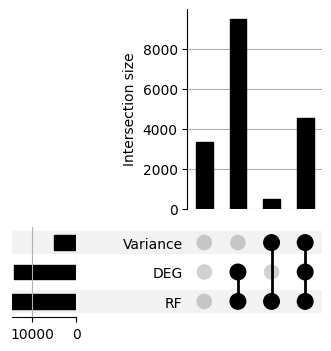

In [99]:
gene_sets = {
    'DEG': genes_DEG,
    'Variance': var_top_genes['Variance_5000'],
    'RF': rf_features_result
}

all_genes = set().union(*gene_sets.values())

memberships = []
for gene in all_genes:
    member_of = [name for name, genes in gene_sets.items() if gene in genes]
    memberships.append(member_of)

upset_data = from_memberships(memberships = memberships)

plot(upset_data, subset_size='count')
plt.show()


## Upset Plot Interpretation
The plot above is called an upset plot, consisting of 3 parts.
- Bottom-left: horizontal bars show the total size of each set
- Bottom-right: dot matrix showing which sets are included in the above bar
- Top: vertical bars show the size of the interection

### Observations
- We can see that a bit more than 4000 genes were identified by all 3 approaches. Increasing the size of the variance sample (using the Variance_10000 column), dramatically increases this number. Using 5000 as our base limit of the total that can overlap to 5000. It may be worth exploring adjusting this number to include more DEGs in our feature set.
- The DEG and RF also appear to have a lot of overlap which is good news that our statistically based DEGs have a lot of overlap with features important for random forest fitting. This suggests that many DEGs truely are important for distinguishing subtypes and ***can*** be used to distinguish subtypes.

After considering different feature sets, I think that using the overlapping set of the top 10000 variance genes, the DEGs, and RF genes would produce a robust set of features (genes). I chose to increase the variance sample from 5000 to 10000 to keep the feature set larger so we don't miss anything. I want to make sure that lower variance genes that may be genuenly helpful are not overlooked due to an overpruned feature set.

## Feature Set
Using a combination of the feature selection methods, we can generate a set of features that overlap 

In [94]:
# Create feature set for classification tasks

gene_counts = {gene: sum(gene in s for s in gene_sets.values()) for gene in all_genes}

min_methods = 3 # select only genes that 3 methods have selected as a feature, for now this is all methods

consensus_genes = [gene for gene, count in gene_counts.items() if count >= min_methods]

print(f'Consensus feature set: {len(consensus_genes)} genes')

X_train_consensus = X_train[consensus_genes]
X_test_consensus = X_test[consensus_genes]


Consensus feature set: 4546 genes


# Building Classifiers
Now that we have defined our feature set can can build and compare classifiers. We will try many classifiers and compare their performance.
## Classifiers
- Random Forest
- Support Vector Machine
- Logistic Regression

In [101]:
# Random Forest
rf = RandomForestClassifier(
    n_estimators = 100, # number of trees
    max_depth = None, # tree depth
    min_samples_leaf = 1, # minimum samples per leaf
    random_state = 1 # for reproducibility
)

In [102]:
# SVM
svc = SVC(
    kernel = 'linear', # can try rbf
    C = 1.0, # regularization
    gamma = 'scale', # can try auto with rbf
    probability = True, # needed for ROC curves
    random_state = 1 # for reproducibility
)

In [ ]:
# Logistic Regression
lr = LogisticRegression(
    penalty = 'l2', # l1, l2, elasticnet (elastinet requires l1_ratio param)
    C = 1.0, # regularization
    solver = 'saga', # supports all penalty types + multinomial (multinomial is default)
    max_iter = 5000, # increase if fails to converge
    random_state = 1 # for reproducibility

)